# Regresión Logística y Regularización — Resumen visual
### Predicción del Éxito Académico en Educación Superior



**Modelo:** Regresión Logística Multinomial (`sklearn.linear_model.LogisticRegression`)  
**Estrategia de selección:** `GridSearchCV` con validación cruzada 5-fold  
**Métricas objetivo:** Macro F1-score (penaliza el desbalanceo entre clases)  
**Clases:** `abandono`, `graduado`, `matriculado`


---
## 1. Búsqueda de hiperparámetros — GridSearchCV

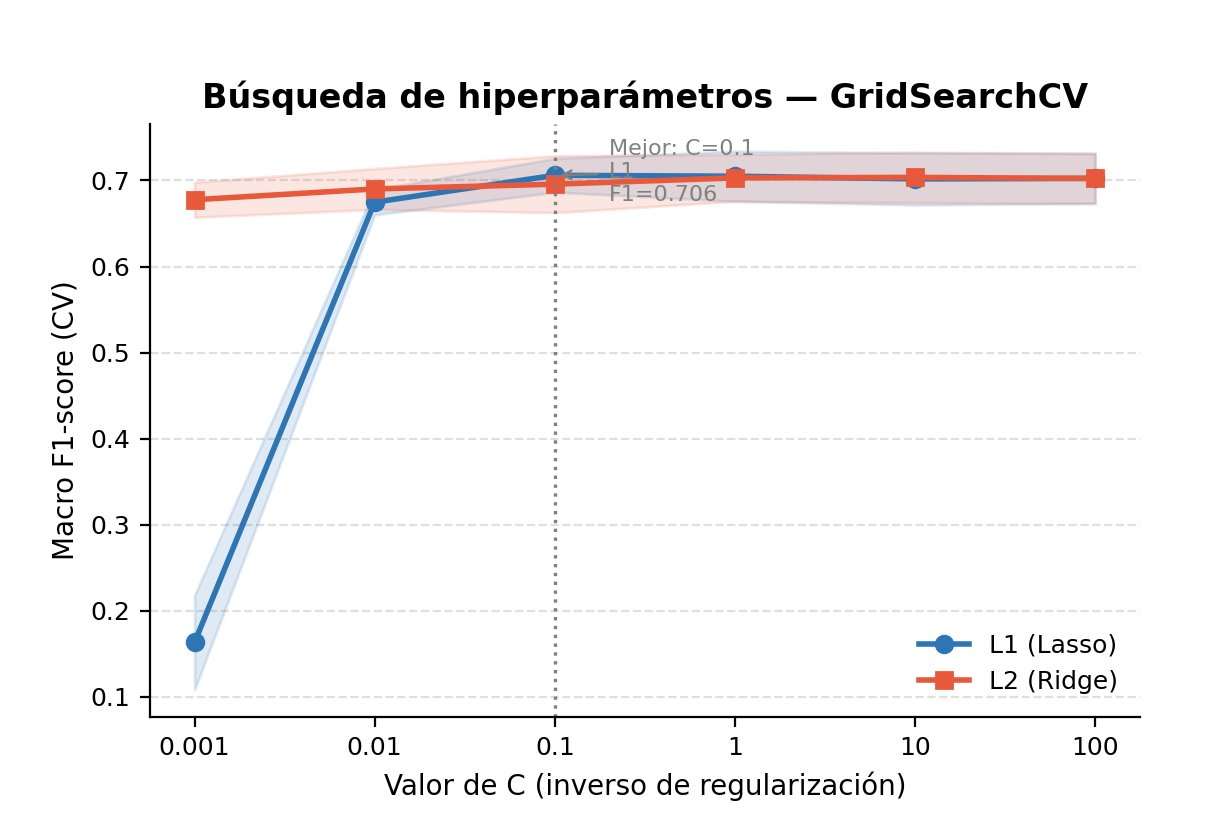

**¿Qué vemos?**
> Estamos viendo cómo hemos barrido los distintos valores de C usando una escala logarítmica para distintos tipos de penalización. C es el inverso de la regularización, por tanto, cuánto más cerca estemos del eje Y, más fuerte es la fuerza regularizadora.

**¿Qué es Macro F1 y porqué lo usamos?**
>Muchas veces se usa la accuracy que mide la proporción de predicciones correctas sobre el total. Sin embargo, es ciego cuando tenemos desbalanceo de clases: por ejemplo, si el modelo clasifica bien los graduados pero estos representan el 50% de los datos tendríamos un accuracy de 50% sin haber aprendido nada de las otras clases!

> F1-score combina dos cosas: Precisión y Recall. La precisión mide, de todos los alumnos que el modelo etiqueta como pertenecientes a una clase, cuántos lo son realmente. El recall mide, de todos los alumnos que realmente pertenecen a esa clase, cuántos consigue detectar el modelo. F1 es la media armónica de ambas medidas por lo que obliga a que las dos sean lo más altas posibles, por eso se castigan mucho más los desequilibrios con F1.

> Macro F1 calcula el F1 de cada clase por separado y luego hace la media simple dando el mismo pesos a las categorías objetivo. Así, fallos en las clases minoritarias cuentan lo mismo que en las mayoritarias.

> Por tanto, el flujo es, por cada fold evaluamos los 5 valores de c para Lasso y Ridge. De ese modo, obtenemos un F1-score por cada valor de c probado con cada función regularizadora. Al final, con Macro F1 obtenemos la media de los F1-score calculados para cada valor de c en todos los folds. En la gráfica vemos la curva azul para Lasso y la curva roja para Ridge y cada punto de la curva representa el Macro F1 obtenido para ese valor de c con esa regularización. Finalmente, escogemos los valores de (c,función regularizadora) que obtienen mayor F1-score : es decir, los hiperparámetros que obtienen mejor Precisión y Recall a la vez, garantizando mejor funcionamiento en TODAS LAS CLASES OBJETIVO.


**¿Por qué L1 colapsa con C=0.001 y L2 no?**
> Lasso añade un término constante al gradiente (sign(w)). Con C muy pequeño (es decir, con mucha regularización) esto provoca una enorme penalización sobre los pesos, llevando muchos directamente hasta 0. El modelo por tanto reduce demasiado su complejidad y predice casi siempre la misma clase. Ridge en cambio no provoca eso ya que por mucho que la fuerza regularizadora sea fuerte, añade un término proporcional a w que hace que los pesos nunca se anulen completamente. Eso hace que no se pierda tantísima complejidad y el modelo pueda seguir discriminando algo.

**Mejor configuración encontrada:** 
`C=0.1`, `penalty=L1`, `Macro F1 = 0.706`
> C = 0.1 es una regularización considerable. Si lo ponemos en contexto vemos que hay 98 features para 2788 filas, eso nos da un ratio de unas 28 muestras por feature. Eso no es una situación de muchísima sobredimensionalidad pero es bastante. El hecho de que necesitemos igual tanta regularización es que hay ruido o multicolinealidad entre features. Esta segunda opción es la que más sentido tiene ya que muchas de las variables del 1er semestre están muy correlacionadas con las del 2do semestra (la tendencia del alumno entre semestres suele ser parecida).
> Por tanto, entendemos también que Lasso termine siendo la función regularizadora elegida ya que su propiedad le permite seleccionar variables redundantes que desestabilizan nuestro modelo.


---
## 2. Matriz de confusión (normalizada por fila)

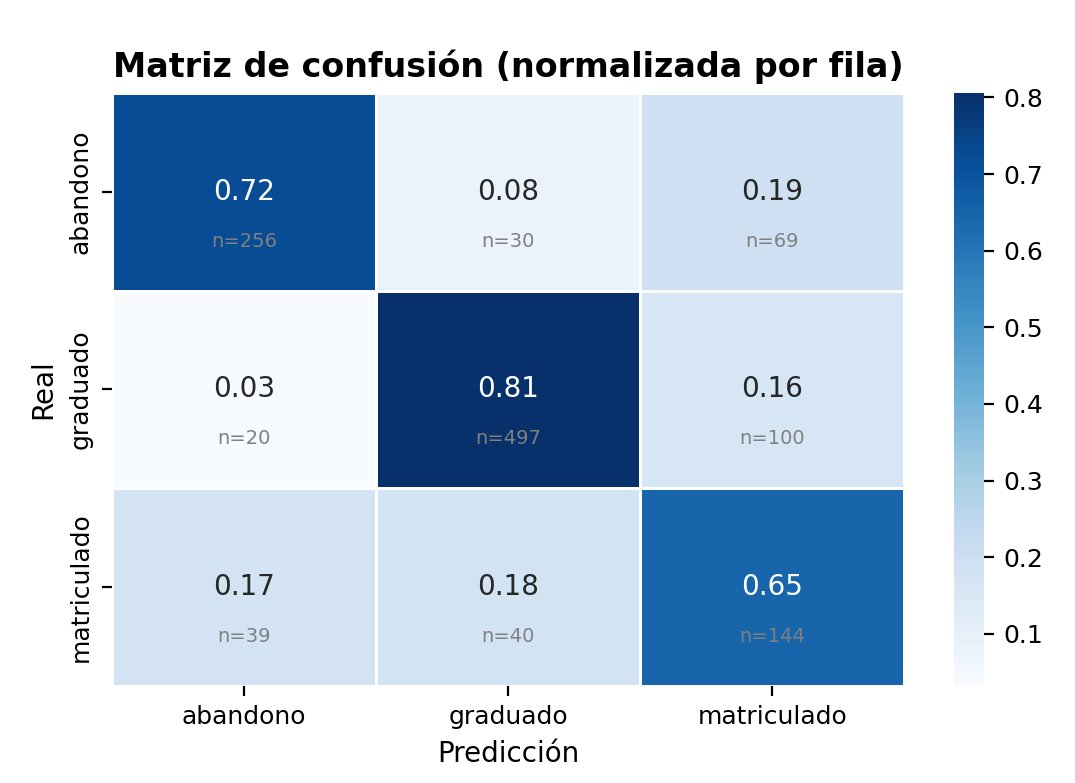

**¿Cómo leer la normalización por fila?**
> Cada fila de la matriz suma 1. Cada posición de la matriz tiene posición (i,j) y se representa en la imagen la proporción de muestras de la clase real i que el modelo predijo como clase j. Esto permite comparar el rendimiento entre clases con independencia del desbalanceo de muestras.

**Resultados clave:**

> - `graduado`: recall = **0.81** — la clase mejor clasificada. Sus features (asignaturas aprobadas, matrícula al día) son muy discriminativas.
> - `abandono`: recall = **0.72** — razonable. El 19% que se confunde con `matriculado` refleja alumnos que aún no han formalizado el abandono.
> - `matriculado`: recall = **0.65** — la más difícil. Comparte características con ambas clases extremas al ser la clase "en tránsito". 
Además es la clase más minoritaria (19% del dataset), lo que agrava el problema.

**Error más común:**
`matriculado` → `graduado` (0.18) y `matriculado` → `abandono` (0.17). 
Ambos errores casi iguales confirman que el modelo no sabe bien "dónde poner" a los matriculados.

> El recall 0.65 en matriculado no es muy bueno pero no es por causa de un fallo de preprocesado sino por varios factores en la naturaleza misma del problema que estamos tratando. Para empezar, matriculado es una clase que es semánticamente ambigua ya que representa unos alumnos en tránsito entre las otras dos categorías objetivo compartiendo muchas de sus características: puede ser un alumno a punto del abandono o un alumno cerca de graduarse... Además, el desbalanceo de clases también limita el rendimiento del modelo ya que a pesar de usar class_weight = "balanced" no terminamos de definir una frontera de decisión bien definida. Más adelante haremos comparativas usando alguna otra técnica para solventar este problema y ver si salen mejores métricas. Además, muchas features del 2do semestre pueden estar incompletas para muchos alumnos que siguen cursando y eso genera ambiguedad.

---
## 3. Precision, Recall y F1 por clase

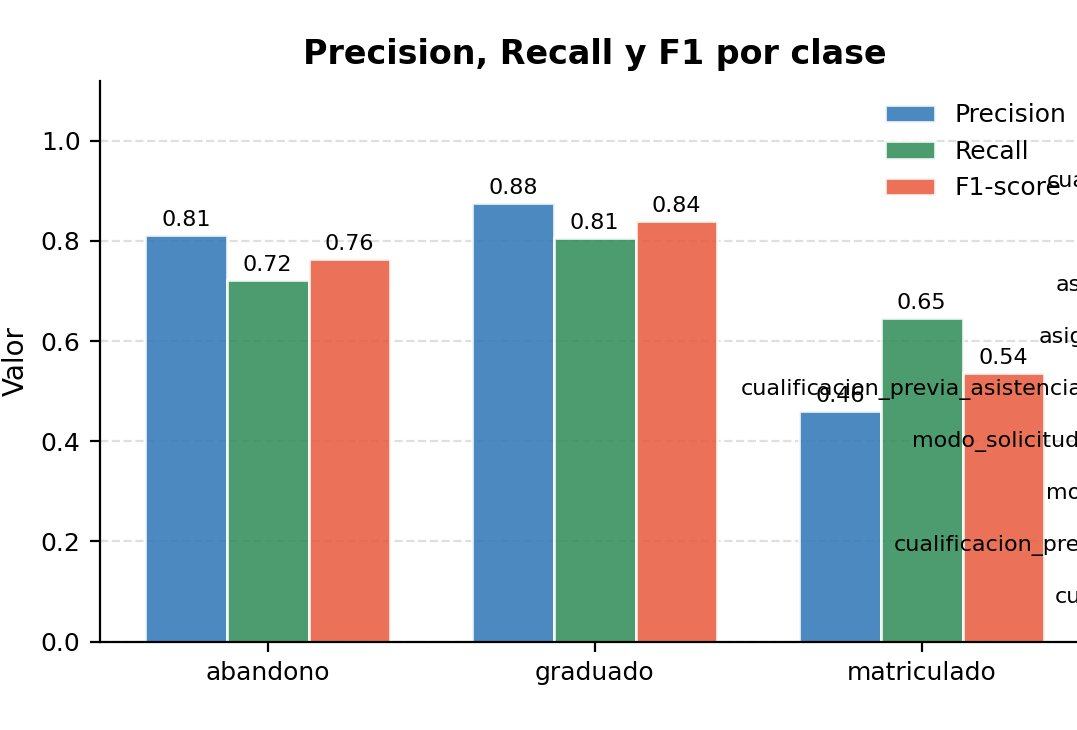


**Análisis por clase:**

> - `graduado` (F1=0.84): tanto precision (0.88) como recall (0.81) altos. Es la clase más fácil y más representada.
> - `abandono` (F1=0.76): precision alta (0.81) pero recall algo menor (0.72). El modelo es conservador: cuando predice abandono casi siempre acierta, pero se le escapan algunos abandonos reales.
> - `matriculado` (F1=0.54): precision baja (0.46) y recall moderado (0.65). Cuando predice matriculado se equivoca más de la mitad de las veces. 
El recall 0.65 (de la matriz de confusión) es el que guía las decisiones: el modelo *encuentra* a bastantes matriculados, pero también genera muchos falsos positivos.

> Como podíamos intuir por lo que venimos viendo, observamos que en la clase matriculado es dónde más problemas surgen y las métricas clásicas lo reflejan.


---
## 4. Top 10 features — clase 'matriculado'

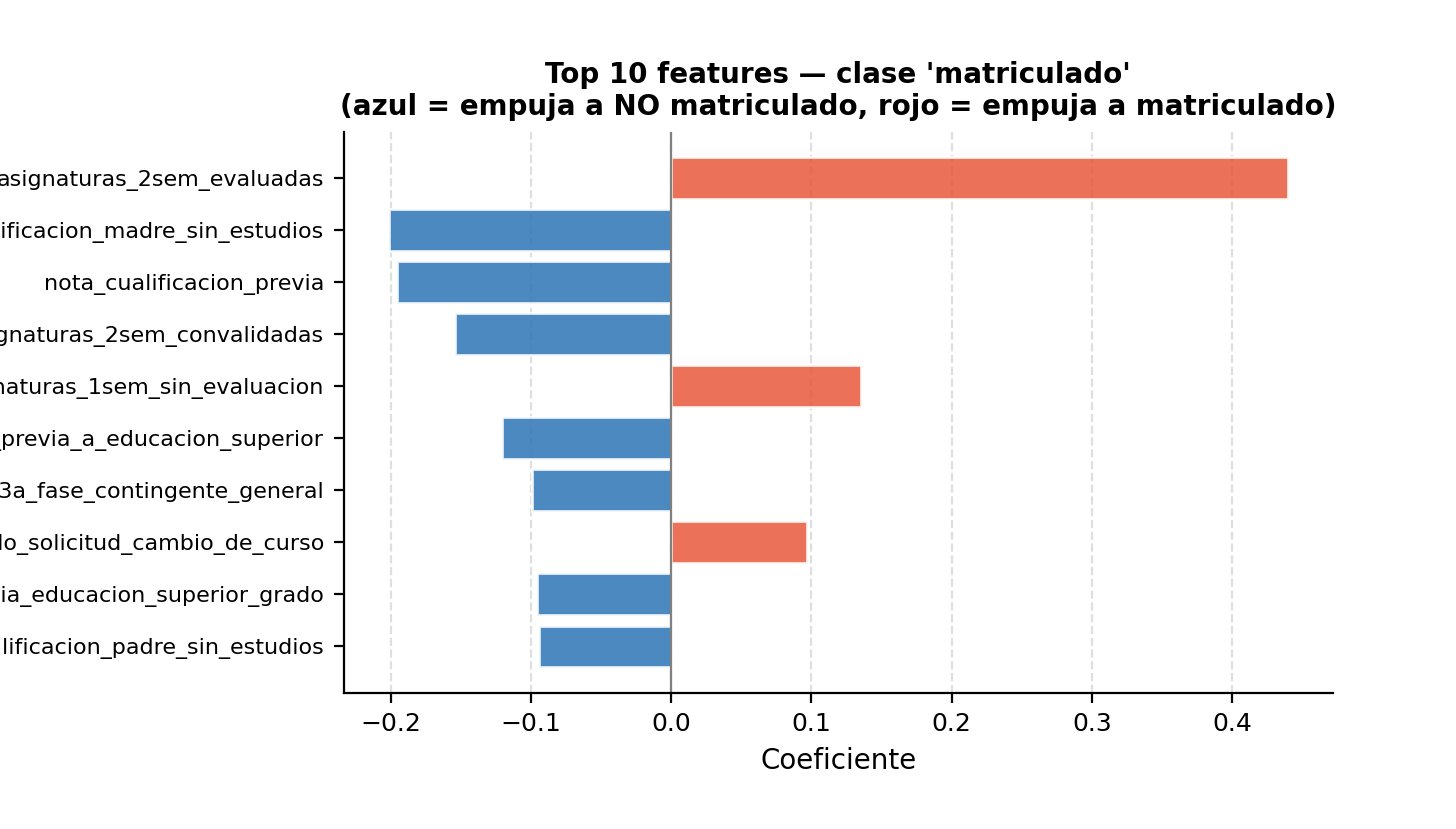

**¿Qué representan estos coeficientes?**
> Cuando hacemos regresión logística multinomial, estamos entrenando un vector de pesos por cada clase. Al ver que la clase de matriculado es la que más problemas nos ha dado, vamos a ver qué featuras han provocado que nuestro modelo decida que el alumno se ha matriculado o no lo ha hecho. Los coeficientes en azul son los que más han pesado al tomar la decisión de que el alumno no se ha matriculado mientras que los rojos al contrario. La estandarización del preprocesado nos permite que los coeficientes sean comparables.

**Interpretación de las features más relevantes:**

> - **`asignaturas_2sem_evaluadas` (+0.43):** Es el coeficiente que más empuja ha decidir que el alumno se ha matriculado. Tiene sentido ya que si el alumno tiene asignaturas del segundo semestre evaluadas es que ha llegado al segundo semestre y se ha presentado a los exámenes. Eso es exactamente el perfil de alguien que sigue matriculado: sigue activo académicamente, no ha abandonado pero tampoco ha terminado aún. Importante recalcar que no es solo esta feature la que decide y que es algo relativo, el modelo tien acceso a todas las features y cuando esto se combina con 2sem aprobadas y nota_media_2sem no tan altas como los graduado ya si que le permite decidir fácilmente
> - **`asignaturas_2_sem_convalidadas`**: Este coeficiente es muy interesante y aunque al principio parece contraintuitivo tiene mucho sentido.  Convalidar significa que el alumno tiene reconocidas esas asignaturas por estudios anteriores por tanto no las tiene que cursar. Entonces, un alumno con muchas convalidadas en el segundo semestre tiene carga académica mucho menor y más probabilidad de terminar antes y graduarse. Por tanto si este coeficiente es alto significa que no necesita presentarse a esas asignaturas porque ya las tiene y probablemente este cerca de graduarse o graduado (no matriculado entonces)
> - **`asignaturas_1sem_sin_evaluacion` (+0.13):** Asignaturas a las que se apuntó pero no llegó a evaluarse. También propio del perfil "en tránsito".
> - **`modo_solicitud_cambio_de_curso` (+0.10):** Alumnos que llegaron por cambio de carrera: más propensos a seguir matriculados (aún probando).
> - **`cualificacion_madre_sin_estudios` (−0.10):** Reduce la probabilidad de `matriculado` → ese perfil se asocia más a abandono. 
> - **`nota_cualificacion_previa` (−0.10):** Una nota previa alta reduce la probabilidad de estar "en tránsito": los alumnos con buen historial tienden a graduarse, no a quedarse matriculados indefinidamente.




> **¿Por qué madre y padre tienen coeficientes similares y no domina el padre?**
Mi intuición antes de ver los resultados era que la situación económica/estudios del padre iban a tener más relevancia que la de la madre a la hora de decidir si hay que matricular al hijo o no.
La explicación obtenida es que en el contexto portgués (que es de donde provienen los datos), la brecha de ingresos entre padre y madre con bajo nivel educativo no es tan pronunciada como en otros contextos
Otra explicación es que usamos Lasso con C = 0.1. Cuando dos variables están correlacionadas entre sí, como lo pueden ser la cualificación del padre y la madre en una misma familia, Lasso tiende a repartir o igualar sus coeficientes en lugar de destacar uno sobre otro.


---
## 5. Análisis de colinealidad — Justificación de Lasso sobre Ridge

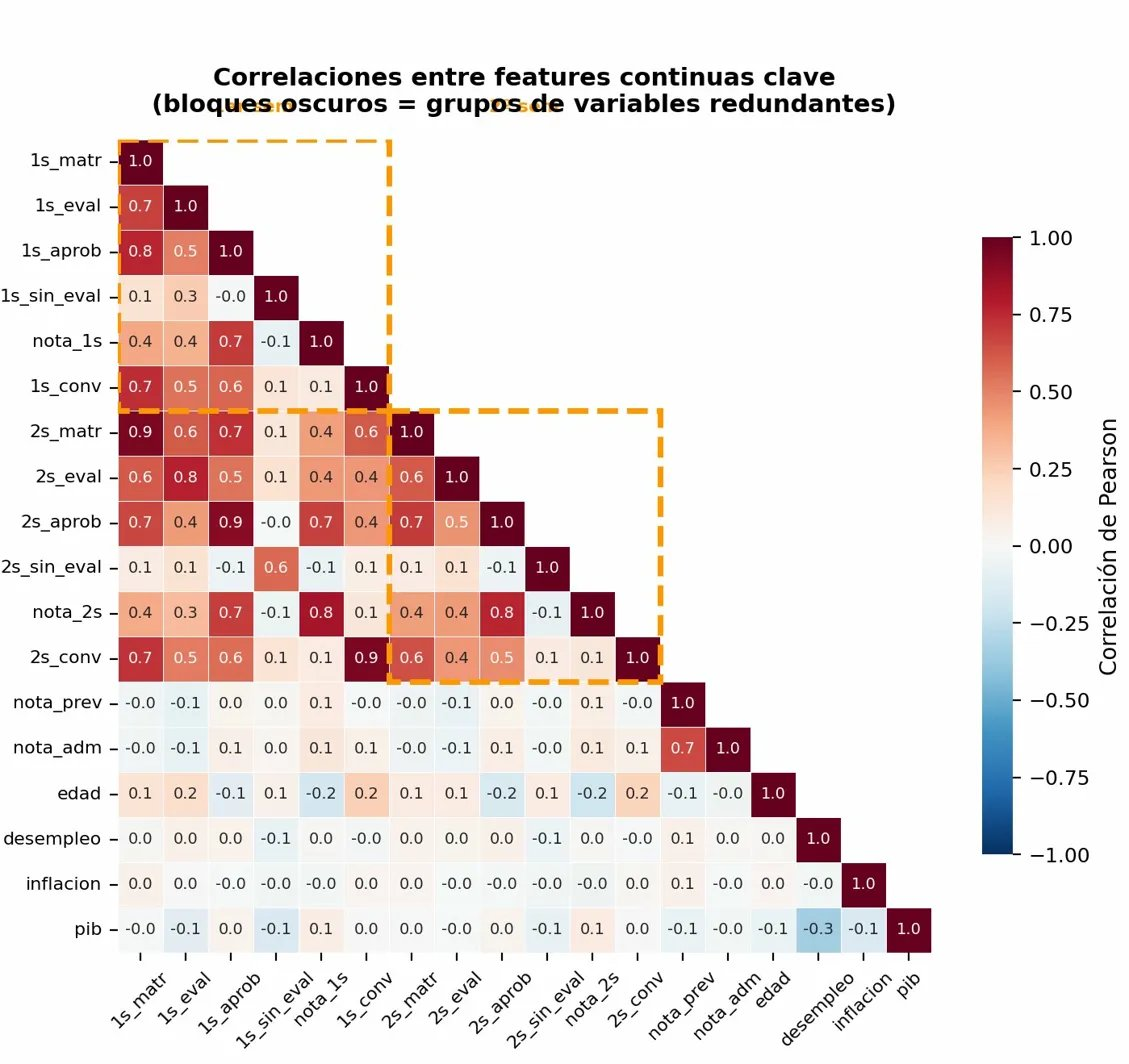

**Panel izquierdo — ¿Qué estamos viendo?**

> El heatmap muestra la **correlación de Pearson** entre las features continuas más relevantes del dataset. 
Los valores cercanos a 1.0 (rojo oscuro) indican que dos variables se mueven prácticamente juntas: cuando una sube, la otra también. 
Los recuadros naranjas destacan los dos bloques de colinealidad más claros: las variables académicas del 1er semestre entre sí, 
y las del 2º semestre entre sí.

**¿Por qué esto justifica Lasso sobre Ridge?**

> Cuando existen grupos de variables altamente correlacionadas, Ridge distribuye el peso entre todas ellas sin decidir cuál es la relevante, 
produciendo muchos coeficientes pequeños pero activos. Lasso en cambio selecciona **una representante por grupo** y lleva el resto a cero. 
Esto produce un modelo más  interpretable, y en nuestro caso obtiene el mismo Macro F1 con muchas menos features activas.


---
## 5. Conclusión — Regresión Logística

<div style="border: 2px solid #2e86c1; border-radius: 8px; padding: 20px 24px; margin: 28px 0; background-color: #eaf4fb; color: #000000;">
<h3 style="color: #1a5276; margin-top: 0; padding-bottom: 8px; border-bottom: 1px solid #aed6f1; margin-bottom: 14px;">Conclusiones finales — Regresión Logística</h3>

Conclusión trás análisis del notebook resumen_regresion_logitstica (los análisis mucho más en profundidad se encuentra en el notebook con las gráficas):
Hemos seguido un hilo conductor que profundiza mucho más que un simple análisis del rendimiento. Primero, hemos buscado los hiperparámetros óptimos y hemos encontrado que la combinación óptima es Lasso con C = 0.1 que es una regularización considerablemente fuerte ya que apuntaba a la existencia de redundancia entre features. Esa hipótesis la hemos confirmado posteriormente con el análisis de colinealidad que nos expuso correlaciones altas entre variables académicas del mismo semestre.
Esto demuestra que el análisis de hiperparámetros no solo optimiza el rendimiento sino que también actúa como diagnóstico del dataset revelando características que han pasado desapercibidas en la fase de preprocesado.
En cuanto al rendimiento, obtenemos resultados sólidos para "abandono"y "graduado" mientras que "matriculado" parece más complicado. Esto no responde a un fallo de nuestro modelo ni del preprocesado sino a la naturaleza ambigua de la clase: los alumnos matriculados son observaciones que están en tránsito que comparten características de perfiles en abandono y graduados.
Finalmente, el análisis de los coeficientes de la clase más problemática nos ha permitido extraer conclusiones académicas y sociológicas relevantes: evaluación en el 2do semestre como indicador de continuidad del alumno o la influencia del nivel educativo de los padres.
La regresión logística demuestra ser no solo un modelo competitivo para este problema sino una herramienta muy útil de interpretabilidad que enriquece la comprensión del dataset.


</div>